In [127]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

import joblib # for saving the model idealy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('C:\\Users\\Administrator\\Desktop\\s stdu\\cis DS\\First ML\\Mall_Customers.csv')
df.info()
print("\n")
df.shape
print(df.isnull().sum())
print("Genres: ",df['Genre'].unique())

print(df.duplicated().sum())
print((df[['Age',
     'Annual Income (k$)',
     'Spending Score (1-100)']] < 0).sum())

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64
Genres:  <ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str
0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


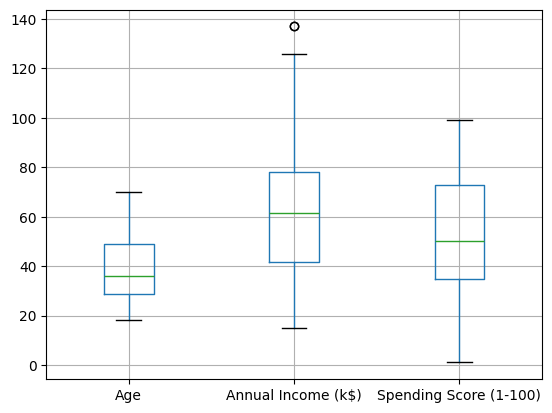

In [128]:
import matplotlib.pyplot as plt

df.boxplot(column=['Age',
                   'Annual Income (k$)',
                   'Spending Score (1-100)'])

plt.show()

clean data , no outliers or missing data 

In [129]:
df.columns
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [130]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Gender was tested (encoded 0/1) but excluded — it produced no clear elbow
and silhouette score never peaked (kept climbing to K=10), suggesting it
added noise rather than structure.

choosing the num of clusters

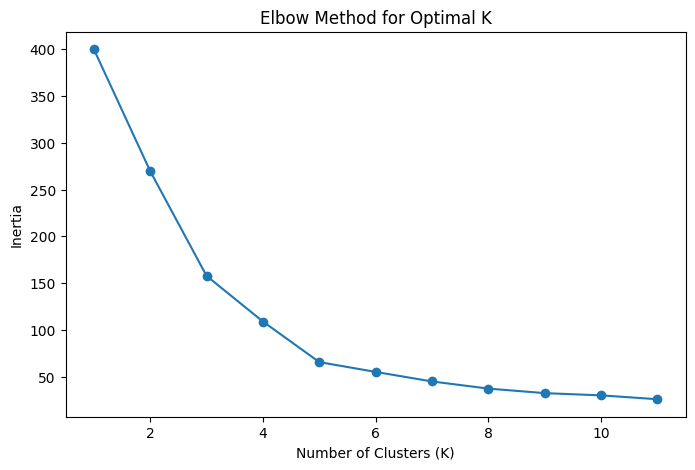

In [131]:
inertia = []

for k in range(1, 12):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 12), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

measuring how well each data point fits within its assigned cluster

In [132]:
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K={k}, silhouette={score:.3f}")

K=2, silhouette=0.321
K=3, silhouette=0.467
K=4, silhouette=0.494
K=5, silhouette=0.555
K=6, silhouette=0.540
K=7, silhouette=0.528
K=8, silhouette=0.455
K=9, silhouette=0.457
K=10, silhouette=0.443


choose k=5 
start final train Kmean model

In [133]:
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels back to the original dataframe
df['Cluster'] = cluster_labels
print(df.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


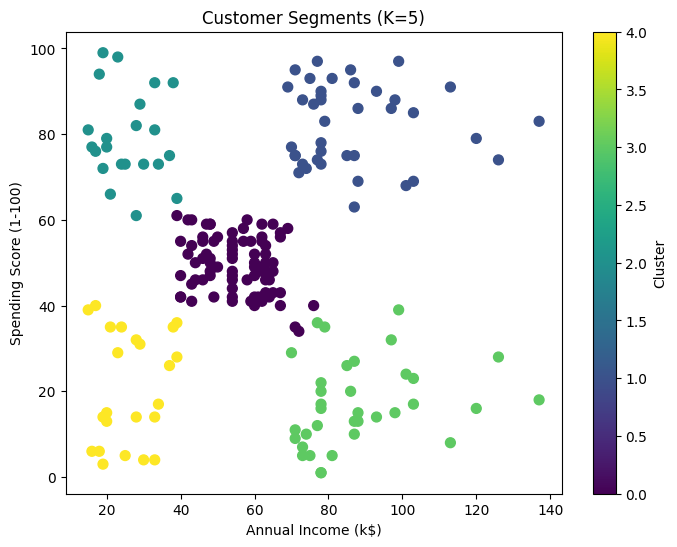

In [134]:
plt.figure(figsize=(8,6))
plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'], 
            c=cluster_labels, cmap='viridis', s=50)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments (K=5)')
plt.colorbar(label='Cluster')


plt.show()

In [135]:
cluster_names = {
    0: "Average Income, Average Spender",
    1: "High Income, High Spender (Target)",
    2: "Low Income, High Spender (Impulsive)",
    3: "High Income, Low Spender (Careful)",
    4: "Low Income, Low Spender (Budget-Conscious)"
}

df['Segment'] = df['Cluster'].map(cluster_names)
print(df[['CustomerID', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster', 'Segment']].head(10))

print(df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean())

   CustomerID  Annual Income (k$)  Spending Score (1-100)  Cluster  \
0           1                  15                      39        4   
1           2                  15                      81        2   
2           3                  16                       6        4   
3           4                  16                      77        2   
4           5                  17                      40        4   
5           6                  17                      76        2   
6           7                  18                       6        4   
7           8                  18                      94        2   
8           9                  19                       3        4   
9          10                  19                      72        2   

                                      Segment  
0  Low Income, Low Spender (Budget-Conscious)  
1        Low Income, High Spender (Impulsive)  
2  Low Income, Low Spender (Budget-Conscious)  
3        Low Income, High Spender (Im

In [136]:
joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']